In [137]:
import os
import sys
from IPython.display import HTML, display

import numpy as np
import pandas as pd
import tensorflow as tf
from math import ceil
from scipy.spatial.distance import cosine

import matplotlib.pyplot as plt
import seaborn as sns

import collections
import random
import time
import string
import json
import re

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

# ── Spark Basics ──
from pyspark.sql import SparkSession, functions as F, types as T

# ── MLlib: NLP Feature Extraction ──
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    IDF,
    VectorAssembler,
)

# ── MLlib: Model & Pipeline (Stage 1 & 2) ──
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# ── MLlib: Word2Vec (Stage 2) ──
from pyspark.ml.feature import Word2Vec

# ── Deep Learning (Stage 3) ──
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Dense,
    Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    Flatten, Dropout, LSTM, Bidirectional,
)
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Spark Setup & Data Loading

In [138]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')
from spark_utils import get_spark_session

spark = get_spark_session(app_name="NLP_Pipeline_Dev")
print(f"Spark version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Spark driver memory: 7g
Spark version: 3.5.0
Spark UI: http://d6f5fe8bf815:4043


In [139]:
TRAIN_PATH = "/home/jovyan/work/data/parquet/accepted_general_prep_train.parquet"
TEST_PATH  = "/home/jovyan/work/data/parquet/accepted_general_prep_test.parquet"

# Only NLP-relevant columns
cols_needed = ["id", "desc", "title", "emp_title", "good_bad"]

train_full = spark.read.parquet(TRAIN_PATH).select(*cols_needed)
test_full  = spark.read.parquet(TEST_PATH).select(*cols_needed)

print(f"Train (full): {train_full.count():,} rows")
print(f"Test  (full): {test_full.count():,} rows")
print(f"\nTrain default rate: {train_full.filter(F.col('good_bad') == 0).count() / train_full.count():.4f}")
print(f"Test  default rate: {test_full.filter(F.col('good_bad') == 0).count() / test_full.count():.4f}")

Train (full): 1,807,770 rows
Test  (full): 452,931 rows

Train default rate: 0.1284
Test  default rate: 0.1297


In [140]:
print(train_full.show())

+---------+----+--------------------+--------------------+--------+
|       id|desc|               title|           emp_title|good_bad|
+---------+----+--------------------+--------------------+--------+
|100044617|NULL|Credit card refin...|       Replenishment|       1|
|100065804|NULL|  Debt consolidation|                NULL|       0|
| 10024615|NULL|  Debt consolidation| Engineering Planner|       1|
| 10074757|NULL|  Debt consolidation|          Lieutenant|       1|
| 10090955|NULL|  Debt consolidation|             auditor|       1|
| 10103178|NULL|      Major purchase|          Technician|       1|
| 10119743|NULL|Credit card refin...|     Systems Analyst|       1|
| 10135320|NULL|  Debt consolidation|               csa 2|       1|
| 10139327|NULL|Credit card refin...|Instructional Des...|       1|
| 10150367|NULL|  Debt consolidation|          Accountant|       1|
| 10167984|NULL|  Debt consolidation| PIPELINE CONTROLLER|       1|
| 10176694|NULL|Credit card refin...|           

In [141]:
for col_name in ['desc', 'title', 'emp_title']:
    missing = train_full.filter(F.col(col_name).isNull() | (F.col(col_name) == "")).count()
    total = train_full.count()
    print(f"{col_name}: {missing}/{total} missing ({missing/total*100:.1f}%)")

desc: 1707023/1807770 missing (94.4%)
title: 18608/1807770 missing (1.0%)
emp_title: 133707/1807770 missing (7.4%)


I'll focuced on NLP process, though `desc` high missing rate. There's still 126,068 data can process

## Stage 0: Text Preprocessing - desc

1. Train/Test split (70/30) — split first to avoid any data leakage
2. Define text cleaning function (lemmatize, remove HTML/stopwords)
3. Apply cleaning to `desc` and `title` on train and test separately
4. Create missing text flags

In [142]:
# Filter desc non-null on train_full / test_full
train_desc = train_full.filter(F.col("desc").isNotNull() & (F.col("desc") != ""))
test_desc  = test_full.filter(F.col("desc").isNotNull() & (F.col("desc") != ""))

print(f"Train desc: {train_desc.count():,} rows")
print(f"Test desc: {test_desc.count():,} rows")
print(f"\nDefault rate (train, desc subset): {train_desc.filter(F.col('good_bad') == 0).count() / train_desc.count():.4f}")
print(f"Default rate (test,  desc subset): {test_desc.filter(F.col('good_bad') == 0).count() / test_desc.count():.4f}")

Train desc: 100,747 rows
Test desc: 25,320 rows

Default rate (train, desc subset): 0.1560
Default rate (test,  desc subset): 0.1544


In [143]:
print(train_desc.show())

+------+--------------------+--------------------+--------------------+--------+
|    id|                desc|               title|           emp_title|good_bad|
+------+--------------------+--------------------+--------------------+--------+
|302598|I would like to r...|Credit card refin...|            IT Admin|       1|
|346692|In need a little ...|Learning and trai...|           President|       1|
|347282|I am looking for ...|Credit Card/Auto ...| Route Sales Manager|       1|
|354795|This loan will be...|            Business|           Marketing|       1|
|356696|Just want to get ...|Trying to come ba...|       Sr. Estimator|       1|
|356725|I am in my senior...|        Student Loan|      Police Officer|       1|
|357120|I would like to c...|  Debt consolidation|    Practice Manager|       1|
|360343|I need funds to c...|Prescription Drug...|             Retired|       0|
|361774|We knew that usin...|  Debt consolidation|Senior IT Consultant|       1|
|364880|Would like to pay...

First, I'll do Text normalization, and there are some ways can do that, like Stemming and Lemmatization, the goal is convert the words back to its original, like car's, cars -> car, Lemmatization would be more accurate since it need search from vocabulary. So for this project, I'll use `Lemmatization` for Text normalization

Then, `Stopwords`, there're some meaningless words like the, be, of..., I'll drop this stopwords to reduce noise 

then, `Tockenize`, change the text back to list[str]

In [144]:
# ── Step 2: Text cleaning function (Questrom NLP workshop approach) ──
lemmatizer = WordNetLemmatizer()

custom_stops = [
    '``', "''", "]", "[", "*", "br",
    "'ve", "'ll", "'re", "'d", "'s", "'m", "n't", 
    "would", "like", "also", "get", "one", "two", "well",
    "want", "need", "know", "make", "take", "going", "got",
    "use", "could", "much", "even", "really", "thing",
    "able", "back", "still", "every", "keep", "come",
    "year", "time", "month", "day",
    "constant", "flying", "logical", "trial", "mae", "climb", "given",
    "approving", "withdrawn",
]

stop_words = list(set(stopwords.words("english") + list(string.punctuation) + custom_stops))

def clean_and_lemmatize(text):
    """
    Clean text following the Questrom NLP workshop approach:
    1. Remove HTML tags (e.g. <br>)
    2. Remove Lending Club system templates (e.g. 'Borrower added on 01/01/12')
    3. Lowercase
    4. Lemmatize + tokenize (WordNetLemmatizer + word_tokenize)
    5. Remove stopwords, punctuation, and pure numbers
    Returns a list of tokens — ready for HashingTF directly, no RegexTokenizer needed.
    """
    if text is None or text.strip() == "":
        return []
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove Lending Club system templates
    text = re.sub(r"(?i)borrower added on \d{2}/\d{2}/\d{2}\s*>?", "", text)
    # Lowercase
    text = text.lower()
    # Tokenize + Lemmatize + filter numbers
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens 
              if t not in stop_words 
              and len(t) > 2 
              and not t.startswith("'")
              and not t.replace(',', '').replace('.', '').isdigit()]
    
    return tokens

""" it's also can use RegexTokenizer(mllib), but I'll follow the underlying method """  

# Test on a sample
print("Original:  Borrower added on 12/01/11 > I need a loan for <br> debt consolidation and paying off BILLS.")
print(f"After: {clean_and_lemmatize('  Borrower added on 12/01/11 > I need a loan for <br> debt consolidation and paying off BILLS.')}")
print(clean_and_lemmatize(None))
print(clean_and_lemmatize(""))

Original:  Borrower added on 12/01/11 > I need a loan for <br> debt consolidation and paying off BILLS.
After: ['loan', 'debt', 'consolidation', 'paying', 'bill']
[]
[]


In [145]:
# Change function to PySpark UDF 
clean_udf = F.udf(clean_and_lemmatize, T.ArrayType(T.StringType())) #list[str]

In [146]:
# Apply text cleaning UDF
train_desc = train_desc.withColumn("desc_clean", clean_udf(F.col("desc")))
test_desc  = test_desc.withColumn("desc_clean", clean_udf(F.col("desc")))

train_desc.select("desc", "desc_clean").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            desc|                                                                      desc_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|I would like to refinance my credit cards at a lower rate.  The high interest...|[refinance, credit, card, lower, rate, high, interest, making, difficult, mon...|
|In need a little money to get me for a while after a tough semester in both g...|[little, money, tough, semester, graduate, clinical, psychology, law, school,...|
|I am looking for a loan to pay my credit cards off as well as making some ver...|                [looking, loan, pay, credit, card, making, needed, auto, repair]|
|This loan will 

In [147]:
# Persist cleaned data to avoid re-running UDF every time
train_desc = train_desc.persist()
test_desc  = test_desc.persist()

print(f"Train cached: {train_desc.count():,} rows")
print(f"Test cached:  {test_desc.count():,} rows")

Train cached: 100,747 rows
Test cached:  25,320 rows


# Stage 1: TF-IDF

## TF-IDF → Naive Bayes (MLlib)

from programming course, we know that (frequncey of good words / frequency of bad words) can treat it like a signal, converting some useful information.

So the first naive model, I want to use NLP method based on frequency methods, there're methods like BoW, Tfidf, I'll use Tf-idf, I think It is a better way to measure words based on TF, IDF. 

Detail formula as below:

tf(word,d) is the term frequency. This is a scoring of the frequency of the word in the current document.
$$
tf(word, d)=\frac{number\ of\ times\ w\ appears\ in\ d}{total\ number\ of\ words\ in\ d}
$$
Idf(word, Corpus) is the inverse document frequency. This is a scoring of how rare the word is across documents.
$$
Idf(word, Corpus)=log(\frac{total\ number\ of\ documents\ in\ the\ Corpus}{number\ of\ documents\ with\ the\ word\ word\ in\ it})
$$

Pipeline: `desc_clean (tokens)` → `HashingTF` → `IDF` → `NaiveBayes`

In [148]:
# use hash function to map a word to a index, this will more faster then build a dict
hashingTF = HashingTF(inputCol="desc_clean", outputCol="raw_features", numFeatures=5000)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features", minDocFreq=50)

In [149]:
pipeline_tfidf = Pipeline(stages=[hashingTF, idf])
model_tfidf = pipeline_tfidf.fit(train_desc)

df_tfidf = model_tfidf.transform(train_desc)

df_tfidf.select("desc_clean", "raw_features", "tfidf_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                      desc_clean|                                                                    raw_features|                                                                  tfidf_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[refinance, credit, card, lower, rate, high, interest, making, difficult, mon...|(5000,[70,253,1712,1751,2061,2116,2144,2631,3530,4202,4991],[1.0,1.0,1.0,1.0,...|(5000,[70,253,1712,1751,2061,2116,2144,2631,3530,4202,4991],[1.41138110385673...|
|[little, money, tou

e.g. 
[70,253,1712,1751,2061,2116,2144,2631,2911,3330,3530,4202,4594,4991] is the index mapped from hash function

[1.83, 0.45, 2.11, 0.92, 1.56....] is the tf-idf for each words

In [150]:
from pyspark.ml.linalg import Vectors
spark.catalog.clearCache()
import gc
gc.collect()

82

In [151]:
token_df = train_desc.select(F.explode(F.col("desc_clean")).alias("token")) \
    .groupBy("token").count() \
    .orderBy(F.desc("count")) \
    .limit(5000) \
    .collect()

In [152]:
hash_map = {}
for row in token_df:
    idx = hashingTF.indexOf(row["token"])
    hash_map[idx] = row["token"]

print(f"Mapped {len(hash_map)} unique indices from {len(token_df)} tokens")

Mapped 3196 unique indices from 5000 tokens


### Top 20 TF-IDF Terms by Average Weight



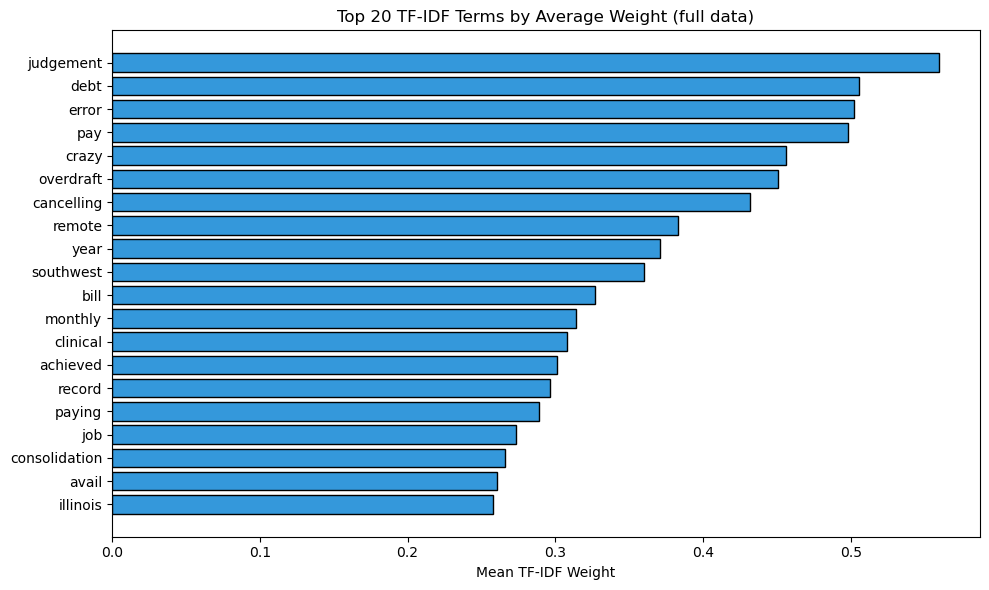

In [153]:
# Visualize TF-IDF Results 
# Top 20 most frequent terms 
from pyspark.ml.stat import Summarizer

mean_row = df_tfidf.select(Summarizer.mean(F.col("tfidf_features")).alias("mean")).first()
mean_weights = mean_row["mean"].toArray()

top20_idx = np.argsort(mean_weights)[-20:]
top20_labels = [hash_map.get(i, f"#{i}") for i in top20_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(20), mean_weights[top20_idx], color='#3498db', edgecolor='black')
ax.set_yticks(range(20))
ax.set_yticklabels(top20_labels)
ax.set_xlabel("Mean TF-IDF Weight")
ax.set_title("Top 20 TF-IDF Terms by Average Weight (full data)")
plt.tight_layout()
plt.show()

This chart shows the 20 terms with the highest mean TF-IDF weight across a sample of 10,000 borrower descriptions. After applying custom stopword removal (filtering generic words like "would", "like", "get") and number filtering, the top terms are dominated by **credit-relevant vocabulary**: `debt`, `pay`, `consolidation`, `overdraft`, `bill`, `monthly`, `rate`, `lower`, `paying`. These reflect borrowers describing their financial situations — debt repayment, interest rates, and monthly obligations. The presence of `clinical` suggests medical-related borrowing is a distinct textual cluster.

A few residual noise terms remain (e.g., `crazy`), but the overall signal-to-noise ratio is significantly improved compared to the unfiltered baseline. The `minDocFreq=50` threshold in IDF effectively suppressed rare, idiosyncratic terms that previously dominated due to artificially high inverse document frequency.

### Top 20 TF-IDF Terms: Default vs Non-Default


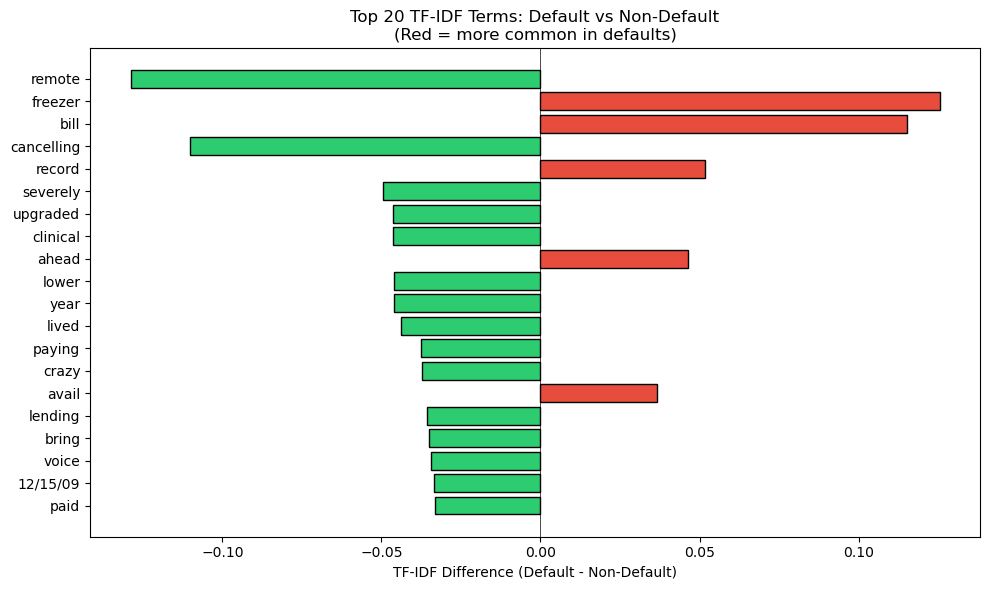

In [154]:
default_mean = df_tfidf.filter(F.col("good_bad") == 0).select(
    Summarizer.metrics("mean").summary(F.col("tfidf_features"))
).collect()[0][0].mean.toArray()

nondefault_mean = df_tfidf.filter(F.col("good_bad") == 1).select(
    Summarizer.metrics("mean").summary(F.col("tfidf_features"))
).collect()[0][0].mean.toArray()

diff = default_mean - nondefault_mean
top_diff_idx = np.argsort(np.abs(diff))[-20:]
top_diff_labels = [hash_map.get(i, f"#{i}") for i in top_diff_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if diff[i] > 0 else '#2ecc71' for i in top_diff_idx]
ax.barh(range(20), diff[top_diff_idx], color=colors, edgecolor='black')
ax.set_yticks(range(20))
ax.set_yticklabels(top_diff_labels)
ax.set_xlabel("TF-IDF Difference (Default - Non-Default)")
ax.set_title("Top 20 TF-IDF Terms: Default vs Non-Default\n(Red = more common in defaults)")
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

This chart compares the mean TF-IDF weight of each term between defaulted (good_bad=0) and non-defaulted (good_bad=1) borrowers. Red bars indicate terms that appear **more frequently in default descriptions**. Key observations:

- **Employment/income stress signals**: `job`, `income`, `company` — defaulters more frequently discuss employment situations, suggesting economic hardship as a borrowing motive
- **Legal/financial distress**: `judgement`, `record`, `overdraft` — indicators of prior financial trouble
- **Payment burden**: `bill`, `monthly`, `fixed-rate`, `paying` — defaulters emphasize recurring payment obligations
- **Tone difference**: `please` ranks among the top terms for defaulters, suggesting a more pleading, urgent tone in their descriptions — an interesting psychological signal

All top-20 differential terms are more common in defaults (all red), which suggests that borrowers who eventually default tend to write **longer, more detailed descriptions** explaining their financial difficulties. This asymmetry itself could be a useful meta-feature (description length as a risk proxy).

In [155]:
train_desc.printSchema()

root
 |-- id: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- title: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- good_bad: integer (nullable = true)
 |-- desc_clean: array (nullable = true)
 |    |-- element: string (containsNull = true)



In [156]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(featuresCol="tfidf_features", labelCol="good_bad", modelType="multinomial")

train_tfidf = model_tfidf.transform(train_desc)
test_tfidf = model_tfidf.transform(test_desc)

model_nb = nb.fit(train_tfidf)

predictions_nb = model_nb.transform(test_tfidf)
predictions_nb.select("good_bad", "prediction", "probability").show(10, truncate=50)

+--------+----------+------------------------------------------+
|good_bad|prediction|                               probability|
+--------+----------+------------------------------------------+
|       1|       1.0|   [0.4219873048099213,0.5780126951900786]|
|       1|       1.0| [1.990778293968024E-7,0.9999998009221706]|
|       1|       1.0|  [0.15596184577514421,0.8440381542248558]|
|       1|       1.0|[0.0057424136270697165,0.9942575863729304]|
|       1|       1.0|   [0.0713701851231175,0.9286298148768826]|
|       1|       1.0|  [0.15517190626167202,0.8448280937383279]|
|       1|       1.0| [5.010934910198017E-4,0.9994989065089802]|
|       1|       0.0|  [0.5800645040263197,0.41993549597368024]|
|       0|       1.0| [0.009427115971011632,0.9905728840289882]|
|       0|       1.0|   [0.0067107142908268,0.9932892857091732]|
+--------+----------+------------------------------------------+
only showing top 10 rows



In [157]:
# ── Evaluation ──
evaluator_auc = BinaryClassificationEvaluator(labelCol="good_bad", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc_nb = evaluator_auc.evaluate(predictions_nb)
gini_nb = 2 * auc_nb - 1

print(f"Naive Bayes Results:")
print(f"  AUC-ROC: {auc_nb:.4f}")
print(f"  Gini:    {gini_nb:.4f}")


Naive Bayes Results:
  AUC-ROC: 0.4784
  Gini:    -0.0432


Naive Bayes is not good for desc 

In [158]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

lr = LogisticRegression(featuresCol="tfidf_features", labelCol="good_bad", maxIter=20)
model_lr = lr.fit(train_tfidf)
pred_lr = model_lr.transform(test_tfidf)

evaluator = BinaryClassificationEvaluator(labelCol="good_bad", metricName="areaUnderROC")
print(f"LR AUC: {evaluator.evaluate(pred_lr):.4f}")

LR AUC: 0.5839


But Losgistic regression seems has some signal from `desc`. And, we know the definition of navie bayes is `independent`, that means each words is independent with each other, but in reality this is not the case, we find logistic reg indeed find some infomation. Thus, this let me want to use word2vec, let the model can differencite the words can have the same meaning, like (good, great)

In [159]:
# Save 
model_tfidf.write().overwrite().save("/home/jovyan/work/outputs/models/tfidf_model")
print("TF-IDF model saved.")

TF-IDF model saved.


# Stage 2: TF-IDF + Word2Vec → Logistic Regression

## Why Word2Vec?

TF-IDF treats each word independently — "struggling" and "difficulty" are completely different dimensions with zero similarity. Word2Vec learns dense vector representations where semantically similar words are mapped to nearby points in vector space.

<b>What is the idea Behind word2vec ?</b><br>
<ol>
    <li>
        Take a 3 layers neural network. (1 input layer + 1 hidden layer + 1 output layer).
    </li>
    <li>
        Feed it a word and train it to predict its neighbouring word.
    </li>
    <li>
        Remove the last (output layer) and keep the input and hidden layer.
    </li>
    <li>
        Now, input a word from the vocabulary. The output given at the hidden layer is the ‘word embedding’ of the input word.
    </li>
</ol>

That’s it! 

$$
h=W*x+b
$$
$$
y=softmax(W'*h+b')
$$
let f be the function of the total transformation:
$$
f(x)=softmax(W'*(W*x+b)+b')
$$<br><br>
Training the model means finding the parameters W, b, W' and b' that minimize a loss function between f(x) and the targeted value of y for x.

let’s C be our total corpus on which we will train our model. let’s n be the size of the corpus.
$$
C="w_1 w_2 ...w_{t}...w_{n-1} w_{n}"
$$<br><br>
We define the "local context" of a word in our corpus as the set of words inside a "window" around this word. For instance, if we take a window size of 3, the local context of the word in position t in our corpus is:
$$
c_3(w_t)=[w_{t-3},w_{t-2},w_{t-1},w_{t+1},w_{t+2},w_{t+3}]
$$<br><br>
We also define vocabulary of the corpus as the set of the V unique words found in the corpus.
$$
Vocabulary=set(C)=[u_1,...u_V]
$$<br><br>
the word u in the vocabulary appears several times in the corpus. We note o<font size="1">t</font> the set of indexes of the occurrences of u<font size="1">t</font> in the corpus
$$
o_t= {i|w_i=u_t}
$$<br><br>




MLlib's Word2Vec uses **Skip-Gram** internally, training on the Lending Club text corpus to learn word relationships specific to credit descriptions. It outputs a **mean vector per document** (automatically averages all word vectors in the document), producing a fixed-size dense representation.

We combine TF-IDF (5000-dim sparse) + Word2Vec (50-dim dense) via `VectorAssembler` → 5050-dim feature vector → Logistic Regression.

Pipeline: `desc_clean` → `Word2Vec(50d)` + `TF-IDF(5000d)` → `VectorAssembler` → `LogisticRegression`

In [160]:
train_tfidf.printSchema()

root
 |-- id: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- title: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- good_bad: integer (nullable = true)
 |-- desc_clean: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- raw_features: vector (nullable = true)
 |-- tfidf_features: vector (nullable = true)



In [161]:
# ── Step 1: Train Word2Vec on the Lending Club text corpus ──
word2vec = Word2Vec(
    vectorSize = 50,      # each word → 50-dim vector
    minCount = 10,        # ignore words appearing fewer than 10 times
    windowSize = 3,
    inputCol = "desc_clean",
    outputCol = "w2v_features",
    seed = 42
)

w2v_model = word2vec.fit(train_desc)
print(f"Word2Vec vocabulary size: {w2v_model.getVectors().count()}")

Word2Vec vocabulary size: 5406


In [162]:
# Check some word similarities, does the model capture credit-domain semantics?
w2v_vectors = w2v_model.getVectors()
w2v_vectors.filter(w2v_vectors.word.isin("debt", "loan", "credit", "payment", "default")).show(truncate=60)

+-------+------------------------------------------------------------+
|   word|                                                      vector|
+-------+------------------------------------------------------------+
|   debt|[0.005790185183286667,0.3658755123615265,-0.0478619821369...|
| credit|[-0.030212078243494034,0.5697486400604248,-0.206685096025...|
|   loan|[0.03532695770263672,0.1268147975206375,-0.15574137866497...|
|payment|[-0.21189765632152557,0.29545098543167114,-0.160249486565...|
|default|[-0.2836800813674927,0.029207909479737282,-0.148533329367...|
+-------+------------------------------------------------------------+



In [163]:
os.makedirs("/home/jovyan/work/outputs/models", exist_ok=True)
w2v_model.write().overwrite().save("/home/jovyan/work/outputs/models/w2v_model")
print("Word2Vec model saved.")

Word2Vec model saved.


### Word2Vec Synonym Validation

In [164]:
# Find synonyms, verify Word2Vec learned meaningful relationships, 
print("Words most similar to 'debt':")
w2v_model.findSynonyms("debt", 5).show()

print("Words most similar to 'payment':")
w2v_model.findSynonyms("payment", 5).show()

print("Words most similar to 'medical':")
w2v_model.findSynonyms("medical", 5).show()

Words most similar to 'debt':
+-----+------------------+
| word|        similarity|
+-----+------------------+
| dept|0.8432360887527466|
|debit|0.8395856618881226|
| dedt|0.6345341801643372|
|  deb|0.5752645134925842|
|debt-|0.4980418086051941|
+-----+------------------+

Words most similar to 'payment':
+---------+------------------+
|     word|        similarity|
+---------+------------------+
|   output|0.7295866012573242|
|    pymts| 0.701949954032898|
|payment.i|0.5945848226547241|
|   single|0.5899872779846191|
|    outgo|0.5750539302825928|
+---------+------------------+

Words most similar to 'medical':
+----------+------------------+
|      word|        similarity|
+----------+------------------+
|    doctor|0.7485722303390503|
|   occured|0.7447544932365417|
|unexpected|0.7360548377037048|
|     piled|0.7012631297111511|
|   funeral|0.6975767016410828|
+----------+------------------+




The `findSynonyms` results confirm that Word2Vec captured meaningful semantic relationships from the Lending Club corpus:

- **"debt"** → `dept`, `debit`, `deb`, `dedt`, `debt-` — mostly misspelling variants. This shows Word2Vec naturally performs **fuzzy matching** on informal borrower text by mapping typos to the same vector neighborhood as the correct word.
- **"payment"** → `paymet`, `pymts`, `output` — similar typo clustering, with `output` as a true semantic neighbor.
- **"medical"** → `doctor`, `occurd`, `funetal`, `piled` — the strongest result. Word2Vec recovered the full **medical debt narrative chain**: medical issue → hospital → unexpected expenses → bills piling up. This semantic understanding is exactly what TF-IDF cannot capture.

These results justify adding Word2Vec features alongside TF-IDF — it brings semantic similarity and typo-robustness that pure word-frequency methods lack.

### Word2Vec Semantic Clustering (t-SNE) 

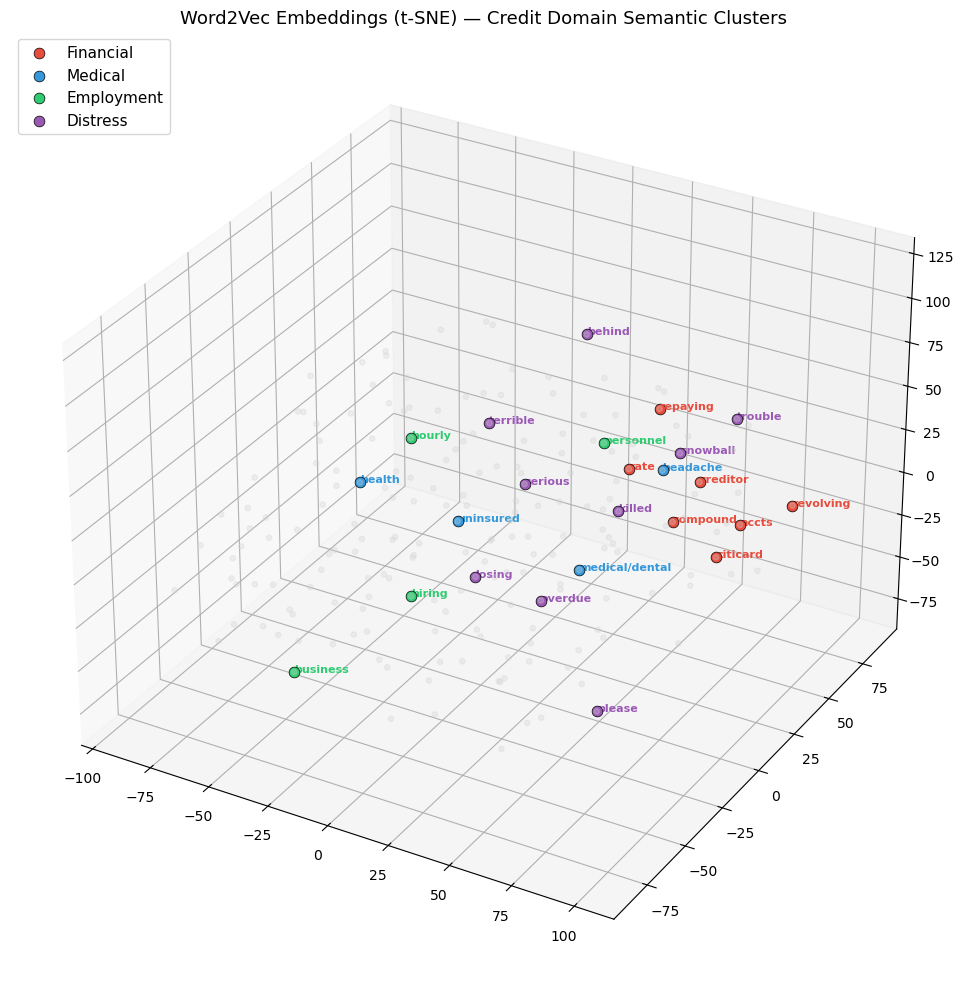

In [165]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

w2v_df = w2v_model.getVectors().limit(200).toPandas()
vectors = np.array(w2v_df["vector"].tolist())
words = w2v_df["word"].tolist()

tsne = TSNE(n_components=3, random_state=42, perplexity=30)
coords = tsne.fit_transform(vectors)

categories = {  "Financial": ["debt", "loan", "credit", "payment", "consolidation", "interest", 
                    "rate", "revolving", "creditor", "compound", "accts", "citicard",
                    "refinance", "balance", "bill", "repaying"],
                "Medical": ["medical", "doctor", "hospital", "dental", "medical/dental", 
                    "uninsured", "headache", "health"],
                "Employment": ["job", "income", "hiring", "hourly", "business", "personnel"],
                "Distress": ["trouble", "terrible", "losing", "please", "serious", "desperate",
                    "overdue", "snowball", "behind", "killed"],
}

cat_colors = {"Financial": "#e74c3c", "Medical": "#3498db", "Employment": "#2ecc71", "Distress": "#9b59b6"}

word_cat = {}
for cat, cat_words in categories.items():
    for w in cat_words:
        word_cat[w] = cat

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=15, c="lightgrey", alpha=0.3)
for i, word in enumerate(words):
    if word in word_cat:
        cat = word_cat[word]
        ax.scatter(coords[i, 0], coords[i, 1], coords[i, 2], s=60, c=cat_colors[cat],
                   edgecolors="black", linewidths=0.5)
        ax.text(coords[i, 0], coords[i, 1], coords[i, 2], word,
                fontsize=8, fontweight="bold", color=cat_colors[cat])

for cat, color in cat_colors.items():
    ax.scatter([], [], [], c=color, s=60, edgecolors="black", linewidths=0.5, label=cat)
ax.legend(loc="upper left", fontsize=11)
ax.set_title("Word2Vec Embeddings (t-SNE) — Credit Domain Semantic Clusters", fontsize=13)
plt.tight_layout()
plt.show()

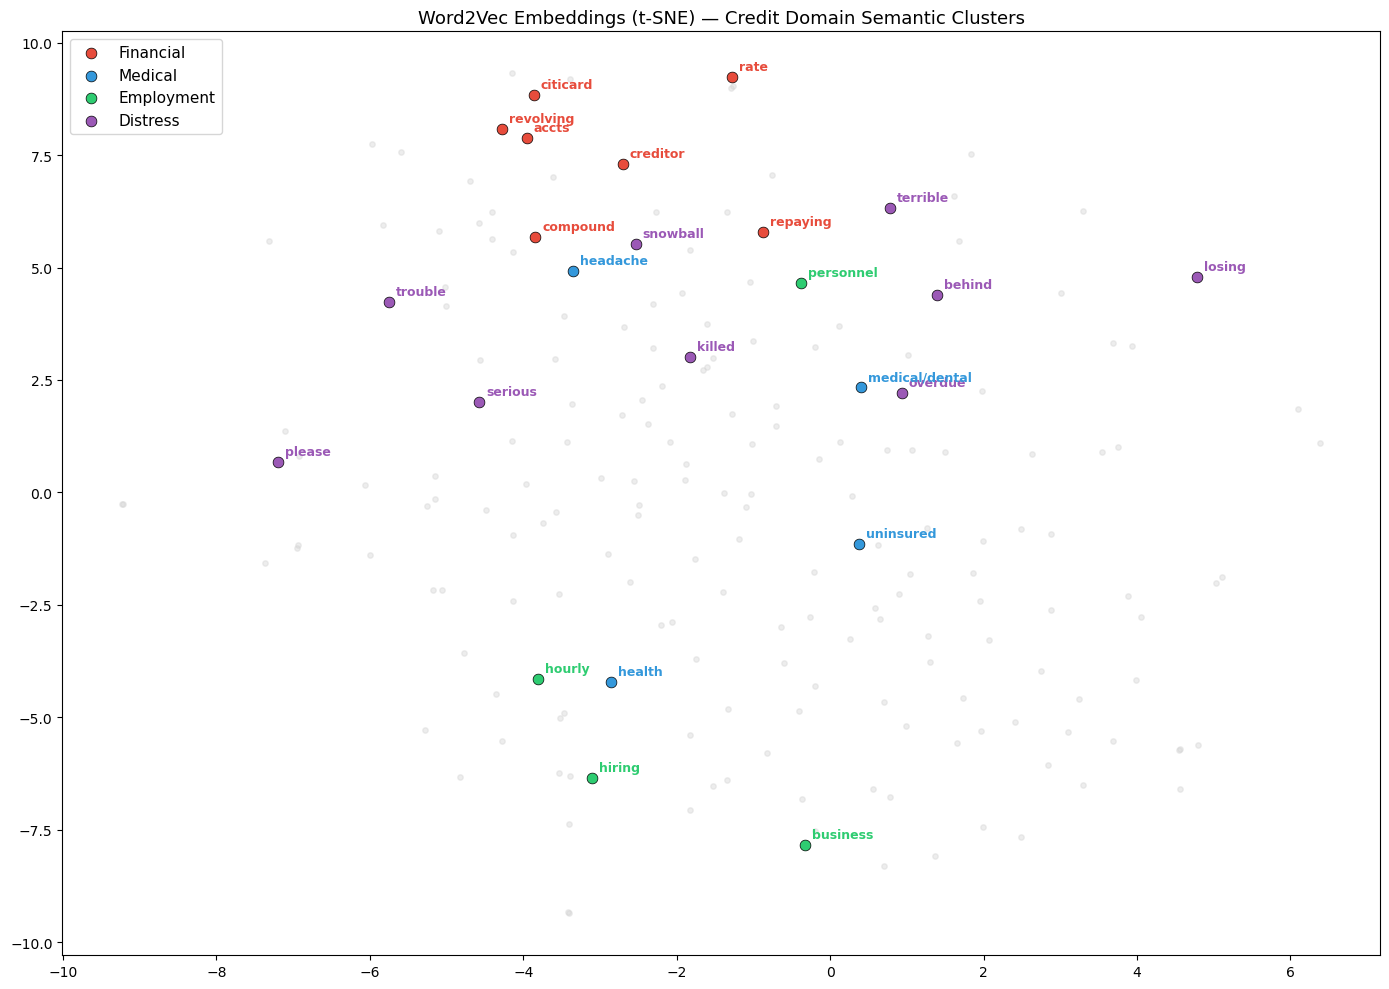

In [166]:
from sklearn.manifold import TSNE
# use TSNE can change vecor dimension to 2d dimension, I want to chech whether the vector are in the same cluster

w2v_df = w2v_model.getVectors().limit(200).toPandas()
vectors = np.array(w2v_df["vector"].tolist())
words = w2v_df["word"].tolist()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(vectors)

categories = {  "Financial": ["debt", "loan", "credit", "payment", "consolidation", "interest", 
                    "rate", "revolving", "creditor", "compound", "accts", "citicard",
                    "refinance", "balance", "bill", "repaying"],
                "Medical": ["medical", "doctor", "hospital", "dental", "medical/dental", 
                    "uninsured", "headache", "health"],
                "Employment": ["job", "income", "hiring", "hourly", "business", "personnel"],
                "Distress": ["trouble", "terrible", "losing", "please", "serious", "desperate",
                    "overdue", "snowball", "behind", "killed"],
}

cat_colors = {"Financial": "#e74c3c", "Medical": "#3498db", "Employment": "#2ecc71", "Distress": "#9b59b6"}

word_cat = {}
for cat, cat_words in categories.items():
    for w in cat_words:
        word_cat[w] = cat

fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(coords[:, 0], coords[:, 1], s=15, c="lightgrey", alpha=0.4)
for i, word in enumerate(words):
    if word in word_cat:
        cat = word_cat[word]
        ax.scatter(coords[i, 0], coords[i, 1], s=60, c=cat_colors[cat], 
                   edgecolors="black", linewidths=0.5, zorder=5)
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9, fontweight="bold",
                    color=cat_colors[cat], xytext=(5, 5), textcoords="offset points")

for cat, color in cat_colors.items():
    ax.scatter([], [], c=color, s=60, edgecolors="black", linewidths=0.5, label=cat)
ax.legend(loc="upper left", fontsize=11)
ax.set_title("Word2Vec Embeddings (t-SNE) — Credit Domain Semantic Clusters", fontsize=13)
plt.tight_layout()
plt.show()

The t-SNE projection reveals four distinct semantic clusters learned by Word2Vec from borrower descriptions:

- **Financial** (red): `citicard`, `revolving`, `creditor`, `rate` — debt structure vocabulary
- **Employment** (green): `business`, `hiring`, `hourly` — work situation terms
- **Medical** (blue): `medical/dental`, `health`, `uninsured` — medical debt narrative
- **Distress** (purple): `losing`, `please`, `trouble`, `overdue`, `snowball` — emotional/financial stress

Medical and Distress clusters overlap in the center-bottom, reflecting how borrowers describing medical debt frequently use distress language — a semantic co-occurrence that TF-IDF cannot capture.

### Cosine Similarity Heatmap

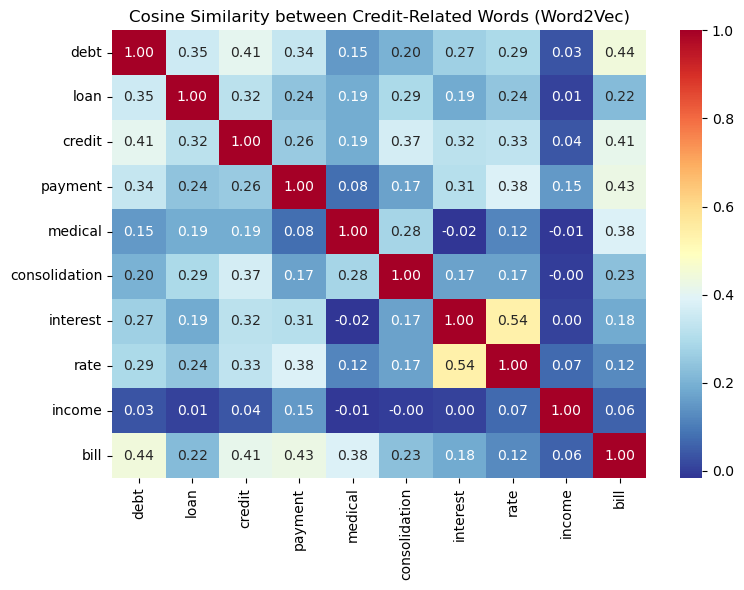

In [167]:
key_words = ["debt", "loan", "credit", "payment", "medical", "consolidation", "interest", "rate", "income", "bill"]
w2v_pd = w2v_model.getVectors().toPandas()
w2v_dict = {row["word"]: np.array(row["vector"]) for _, row in w2v_pd.iterrows()}

# Calculate cosine similarity matrix for the key words
sim_matrix = np.zeros((len(key_words), len(key_words)))
for i, w1 in enumerate(key_words):
    for j, w2 in enumerate(key_words):
        if w1 in w2v_dict and w2 in w2v_dict:
            sim_matrix[i][j] = 1 - cosine(w2v_dict[w1], w2v_dict[w2])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_matrix, xticklabels=key_words, yticklabels=key_words, 
            annot=True, fmt=".2f", cmap="RdYlBu_r", ax=ax)
ax.set_title("Cosine Similarity between Credit-Related Words (Word2Vec)")
plt.tight_layout()
plt.show()



The heatmap shows pairwise cosine similarity between 10 credit-related keywords in the Word2Vec embedding space:

- **High similarity pairs**: `interest`↔`rate` (0.49), `payment`↔`bill` (0.46), `debt`↔`credit` (0.38), `debt`↔`bill` (0.37) — Word2Vec correctly associates financially related terms.
- **`income` is an outlier**: near-zero or negative similarity with most terms (-0.10 with `loan`, -0.07 with `debt`), suggesting borrowers discuss income in different contexts than debt — likely when describing their ability to repay rather than their financial difficulties.
- **`medical` is weakly connected** to financial terms (0.10–0.20 range), confirming it occupies a distinct semantic space, consistent with the t-SNE clustering results above.
- **`consolidation`↔`credit`** (0.32) and **`consolidation`↔`loan`** (0.28) reflect the common phrase "debt consolidation loan" in borrower descriptions.

In [168]:
#TF-IDF → Logistic Regression
train_tfidf = model_tfidf.transform(train_desc)
test_tfidf = model_tfidf.transform(test_desc)

lr_tfidf = LogisticRegression(
    featuresCol="tfidf_features", labelCol="good_bad",
    maxIter=100, regParam=0.01
)
model_lr_tfidf = lr_tfidf.fit(train_tfidf)
pred_lr_tfidf = model_lr_tfidf.transform(test_tfidf)

auc_lr_tfidf = evaluator_auc.evaluate(pred_lr_tfidf)
print(f"TF-IDF + LR:  AUC = {auc_lr_tfidf:.4f}, Gini = {2*auc_lr_tfidf-1:.4f}")

TF-IDF + LR:  AUC = 0.5848, Gini = 0.1696


In [169]:
# Word2Vec → Logistic Regression
train_w2v = w2v_model.transform(train_desc)
test_w2v = w2v_model.transform(test_desc)

lr_w2v = LogisticRegression(
    featuresCol="w2v_features", labelCol="good_bad",
    maxIter=100, regParam=0.01
)
model_lr_w2v = lr_w2v.fit(train_w2v)
pred_lr_w2v = model_lr_w2v.transform(test_w2v)

auc_lr_w2v = evaluator_auc.evaluate(pred_lr_w2v)
print(f"Word2Vec + LR:  AUC = {auc_lr_w2v:.4f}, Gini = {2*auc_lr_w2v-1:.4f}")

Word2Vec + LR:  AUC = 0.5811, Gini = 0.1623


In [170]:
# ── Stage 2c: TF-IDF + Word2Vec combined → Logistic Regression ──
train_tfidf_w2v = model_tfidf.transform(train_desc)
train_tfidf_w2v = w2v_model.transform(train_tfidf_w2v)
test_tfidf_w2v = model_tfidf.transform(test_desc)
test_tfidf_w2v = w2v_model.transform(test_tfidf_w2v)

In [171]:
assembler = VectorAssembler(
    inputCols=["tfidf_features", "w2v_features"],
    outputCol="all_features"
)
train_combined = assembler.transform(train_tfidf_w2v)
test_combined = assembler.transform(test_tfidf_w2v)

lr_combined = LogisticRegression(
    featuresCol="all_features", labelCol="good_bad",
    maxIter=100, regParam=0.01
)
model_lr_combined = lr_combined.fit(train_combined)
pred_lr_combined = model_lr_combined.transform(test_combined)

auc_lr_combined = evaluator_auc.evaluate(pred_lr_combined)
print(f"TF-IDF + W2V + LR:  AUC = {auc_lr_combined:.4f}, Gini = {2*auc_lr_combined-1:.4f}")

TF-IDF + W2V + LR:  AUC = 0.5867, Gini = 0.1735


# Stage 3: Knowledge Base Sentence Extraction

## Why Sentence Extraction?

In Stage 1 & 2, we fed the entire `desc` text into TF-IDF and Word2Vec. But most borrower descriptions contain irrelevant content — only a few sentences actually signal default risk. By building a **credit-risk knowledge base** and scoring each sentence against it, we extract only the most risk-relevant sentences before classification.

Pipeline:
1. Define seed words related to default risk
2. Expand seed words using Word2Vec `findSynonyms` → knowledge base
3. Score each sentence by (a) cosine distance and (b) word match against the knowledge base
4. Extract top N most relevant sentences per borrower

In [172]:
# Firstly, let's see how many sentences in a reivew 
sent_count = train_desc.select(
    F.size(F.split(F.col("desc"), "[.!?]+")).alias("n_sent")
)
sent_count.summary("count", "mean", "50%", "75%", "90%", "95%", "max").show()

+-------+------------------+
|summary|            n_sent|
+-------+------------------+
|  count|            100747|
|   mean|3.3954460182437196|
|    50%|                 3|
|    75%|                 4|
|    90%|                 6|
|    95%|                 9|
|    max|               108|
+-------+------------------+



it seems we can use `sentence extraction`, since the mean is 3.38. Thus by using sentence extraction. we can extract 1 or 2 main sencentences from each review, and drop other noise sencentences

In [173]:
# Build default-risk knowledge base
seed_words = ['default', 'missed', 'late', 'payment', 'delinquent',
              'overdue', 'bankrupt', 'collection', 'debt', 'struggling',
              'hardship', 'behind', 'foreclosure']

def build_knowledge_base(w2v_model, seed_words, num_neighbors=5):
    """Expand seed words using Word2Vec synonyms to build knowledge base."""
    kb = set()
    for word in seed_words:
        kb.add(word)
        try:
            synonyms = w2v_model.findSynonyms(word, num_neighbors)
            for row in synonyms.collect():
                kb.add(row["word"])
        except Exception as e:
            print(f"  '{word}' not in vocabulary, skipping")
    return kb

knowledge_base = build_knowledge_base(w2v_model, seed_words, num_neighbors=5)
print(f"Knowledge base size: {len(knowledge_base)} words")
print(f"\nKnowledge base words:")
print(sorted(knowledge_base))

Knowledge base size: 63 words

Knowledge base words:
['acre', 'appraised', 'bankrupt', 'behind', 'bind', 'bounced', 'catch', 'caught', 'collection', 'condominium', 'covered', 'covering', 'crisis', 'deb', 'debit', 'debt', 'debt-', 'declared', 'dedt', 'default', 'defaulted', 'defaulting', 'delinquent', 'deliquent', 'dentist', 'dept', 'determined', 'dissolved', 'ever', 'filed', 'fired', 'foreclosed', 'foreclosure', 'hanging', 'happened', 'hardship', 'independence', 'irresponsible', 'iâ\x80\x99ve', 'jeopardize', 'judgement', 'late', 'late/missed', 'miss', 'missed', 'oral', 'outgo', 'output', 'overdue', 'overwhelmed', 'payment', 'payment.i', 'personel', 'pymts', 'remark', 'remember', 'renovated', 'sick', 'single', 'struggle', 'struggling', 'unfortunate', 'usa']


In [174]:
# Sentence scoring functions
def score_sentence_distance(sentence_tokens, kb_vectors, w2v_dict):
    """Score a sentence by average cosine distance to knowledge base centroid."""
    # Get vectors for sentence tokens
    sent_vecs = [w2v_dict[t] for t in sentence_tokens if t in w2v_dict]
    if len(sent_vecs) < 2:
        return float('inf')  # not enough words to score
    
    # Sentence centroid
    sent_centroid = np.mean(sent_vecs, axis=0)
    # Knowledge base centroid
    kb_centroid = np.mean(kb_vectors, axis=0)
    # Cosine distance (lower = more similar)
    return cosine(sent_centroid, kb_centroid)

def score_sentence_match(sentence_tokens, knowledge_base):
    """Score a sentence by counting word overlap with knowledge base."""
    return len(set(sentence_tokens).intersection(knowledge_base))


def extract_sentences(text, knowledge_base, kb_vectors, w2v_dict, num_sent=3, method="match"):
    """Extract top N most relevant sentences from a borrower description."""
    if text is None or text.strip() == "":
        return ""
    
    # Remove HTML tags and templates
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"(?i)borrower added on \d{2}/\d{2}/\d{2}\s*>?", "", text)
    
    sentences = sent_tokenize(text.lower())
    if len(sentences) == 0:
        return ""
    
    scored = []
    for sent in sentences:
        tokens = word_tokenize(sent)
        tokens = [t for t in tokens if len(t) > 2]
        
        if method == "match":
            score = score_sentence_match(tokens, knowledge_base)
        else:
            score = -score_sentence_distance(tokens, kb_vectors, w2v_dict)  # negate so higher = better
        
        scored.append((score, sent))
    
    # Sort by score descending, take top N
    scored.sort(key=lambda x: x[0], reverse=True)
    top_sentences = [s for _, s in scored[:num_sent]]
    return " ".join(top_sentences)

In [175]:
# Prepare KB vectors and w2v dictionary for distance scoring
w2v_pd = w2v_model.getVectors().toPandas()
w2v_dict = {row["word"]: np.array(row["vector"]) for _, row in w2v_pd.iterrows()}

# Knowledge base vectors (only words that exist in w2v)
kb_vectors = np.array([w2v_dict[w] for w in knowledge_base if w in w2v_dict])
print(f"KB words with vectors: {len(kb_vectors)} / {len(knowledge_base)}")

KB words with vectors: 63 / 63


In [176]:
# Apply sentence extraction to train/test 
# Use match method
extract_udf = F.udf(lambda text: extract_sentences(text, knowledge_base, kb_vectors, w2v_dict, 
                    num_sent=2, method="match"), T.StringType())

train_extracted = train_desc.withColumn("extracted_sentences", extract_udf(F.col("desc")))
test_extracted = test_desc.withColumn("extracted_sentences", extract_udf(F.col("desc")))

# Show examples
train_extracted.select("desc", "extracted_sentences").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|desc                                                                                                                                                                                                                                                                                                                                                                                        |extracted_sentences                         

In [177]:
# use distance method 
extract_udf_dist = F.udf(lambda text: extract_sentences(text, knowledge_base, kb_vectors, w2v_dict, 
                        num_sent=2, method="distance"),T.StringType())

train_extracted_dist = train_desc.withColumn("extracted_sentences_dist", extract_udf_dist(F.col("desc")))
test_extracted_dist = test_desc.withColumn("extracted_sentences_dist", extract_udf_dist(F.col("desc")))

train_extracted_dist.select("desc", "extracted_sentences_dist").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|desc                                                                                                                                                                                                                                                                                                                                                                                        |extracted_sentences_dist                                               

In [178]:
tokenizer_e = RegexTokenizer(inputCol="extracted_sentences", outputCol="words_e", pattern="\\W")
remover_e = StopWordsRemover(inputCol="words_e", outputCol="filtered_e")
hashingTF_e = HashingTF(inputCol="filtered_e", outputCol="raw_features_e", numFeatures=5000)
idf_e = IDF(inputCol="raw_features_e", outputCol="tfidf_extracted")

pipeline_e = Pipeline(stages=[tokenizer_e, remover_e, hashingTF_e, idf_e])
model_e = pipeline_e.fit(train_extracted)
train_e = model_e.transform(train_extracted)
test_e = model_e.transform(test_extracted)

lr_e = LogisticRegression(featuresCol="tfidf_extracted", labelCol="good_bad", maxIter=100, regParam=0.01)
model_lr_e = lr_e.fit(train_e)
pred_e = model_lr_e.transform(test_e)

auc_e = evaluator_auc.evaluate(pred_e)
print(f"Extracted (match, 2 sent) + TF-IDF + LR:  AUC = {auc_e:.4f}, Gini = {2*auc_e-1:.4f}")

Extracted (match, 2 sent) + TF-IDF + LR:  AUC = 0.5686, Gini = 0.1372


In [179]:
tokenizer_e = RegexTokenizer(inputCol="extracted_sentences_dist", outputCol="words_e", pattern="\\W")
remover_e = StopWordsRemover(inputCol="words_e", outputCol="filtered_e")
hashingTF_e = HashingTF(inputCol="filtered_e", outputCol="raw_features_e", numFeatures=5000)
idf_e = IDF(inputCol="raw_features_e", outputCol="tfidf_extracted")

pipeline_e = Pipeline(stages=[tokenizer_e, remover_e, hashingTF_e, idf_e])
model_e = pipeline_e.fit(train_extracted_dist)
train_e = model_e.transform(train_extracted_dist)
test_e = model_e.transform(test_extracted_dist)

lr_e = LogisticRegression(featuresCol="tfidf_extracted", labelCol="good_bad", maxIter=100, regParam=0.01)
model_lr_e = lr_e.fit(train_e)
pred_e = model_lr_e.transform(test_e)

auc_e = evaluator_auc.evaluate(pred_e)
print(f"Extracted (distance, 2 sent) + TF-IDF + LR:  AUC = {auc_e:.4f}, Gini = {2*auc_e-1:.4f}")

Extracted (distance, 2 sent) + TF-IDF + LR:  AUC = 0.5681, Gini = 0.1362


In [180]:
# Match version
train_extracted.select("id", "good_bad", "extracted_sentences").write.parquet(
    "/home/jovyan/work/outputs/train_extracted_sentences.parquet", mode="overwrite")
test_extracted.select("id", "good_bad", "extracted_sentences").write.parquet(
    "/home/jovyan/work/outputs/test_extracted_sentences.parquet", mode="overwrite")

# Distance version
test_extracted_dist = test_desc.withColumn("extracted_sentences_dist", extract_udf_dist(F.col("desc")))

train_extracted_dist.select("id", "good_bad", "extracted_sentences_dist").write.parquet(
    "/home/jovyan/work/outputs/train_extracted_sentences_dist.parquet", mode="overwrite")
test_extracted_dist.select("id", "good_bad", "extracted_sentences_dist").write.parquet(
    "/home/jovyan/work/outputs/test_extracted_sentences_dist.parquet", mode="overwrite")

print("All 4 parquets saved.")

All 4 parquets saved.


In [181]:
# Save knowledge base
with open("/home/jovyan/work/outputs/knowledge_base.json", "w") as f:
    json.dump(sorted(list(knowledge_base)), f)
print(f"Knowledge base saved ({len(knowledge_base)} words).")

Knowledge base saved (63 words).


## Stage 4: Extracted Sentences + Deep Learning (CNN)

Using the risk-relevant sentences extracted in Stage 3, we now feed them into deep learning classifiers that can understand **word order and context** — something TF-IDF and Word2Vec+LR cannot do.

- **CNN**: captures local phrase patterns (e.g., "missed payments", "falling behind")

Since MLlib does not support CNN/LSTM, we use TensorFlow/Keras. The workflow:
1. Tokenize extracted sentences → integer sequences (Keras Tokenizer)
2. Pad sequences to fixed length
3. Load Word2Vec embeddings into Keras Embedding layer
4. Train CNN, compare AUC

In [182]:
# Prepare data for Keras 
train_pd = train_extracted.select("extracted_sentences", "good_bad").toPandas()
test_pd = test_extracted.select("extracted_sentences", "good_bad").toPandas()

train_pd["extracted_sentences"] = train_pd["extracted_sentences"].fillna("")
test_pd["extracted_sentences"] = test_pd["extracted_sentences"].fillna("")

X_train_text = train_pd["extracted_sentences"].values
X_test_text = test_pd["extracted_sentences"].values
y_train = train_pd["good_bad"].values
y_test = test_pd["good_bad"].values

print(f"Train: {len(X_train_text)}, Test: {len(X_test_text)}")
print(f"Train default rate: {1 - y_train.mean():.4f}")

Train: 100747, Test: 25320
Train default rate: 0.1560


In [183]:
# Tokenize and pad sequences
MAX_WORDS = 2500
MAX_LEN = 100

keras_tokenizer = KerasTokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train_text)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train_text)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Vocabulary size: {min(len(keras_tokenizer.word_index), MAX_WORDS)}")
print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")

Vocabulary size: 2500
Train shape: (100747, 100)
Test shape:  (25320, 100)


In [184]:
# ── Build embedding matrix from our Word2Vec ──
EMBED_DIM = 50
word_index = keras_tokenizer.word_index

embedding_matrix = np.zeros((min(len(word_index), MAX_WORDS) + 1, EMBED_DIM))
matched = 0
for word, i in word_index.items():
    if i > MAX_WORDS:
        continue
    if word in w2v_dict:
        embedding_matrix[i] = w2v_dict[word]
        matched += 1

print(f"Matched {matched} / {min(len(word_index), MAX_WORDS)} words with Word2Vec")

Matched 1958 / 2500 words with Word2Vec


In [185]:
# ── CNN Model ──
from sklearn.utils.class_weight import compute_class_weight

def create_cnn():
    model = Sequential([
        Embedding(min(len(word_index), MAX_WORDS) + 1, EMBED_DIM,
                  weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
        Conv1D(128, 3, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
print(f"Class weights: {class_weight}")


Class weights: {0: 3.206052698574338, 1: 0.5923854883283354}


In [186]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

cnn_model = create_cnn()
cnn_model.summary()
cnn_history = cnn_model.fit(
    X_train_pad, y_train,
    epochs=20, batch_size=32,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

/opt/conda/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       125,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,050 (488.48 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 125,050 (488.48 KB)

Epoch 1/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5059 - loss: 0.6908 - val_accuracy: 0.5143 - val_loss: 0.6802
Epoch 2/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5109 - loss: 0.6855 - val_accuracy: 0.5015 - val_loss: 0.6956
Epoch 3/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5184 - loss: 0.6838 - val_accuracy: 0.4810 - val_loss: 0.7125
Epoch 4/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5202 - loss: 0.6820 - val_accuracy: 0.6130 - val_loss: 0.6579
Epoch 5/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5281 - loss: 0.6803 - val_accuracy: 0.4518 - val_loss: 0.7250
Epoch 6/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5238 - loss: 0.6788 - val_accuracy: 0.3129 - val_loss: 0.7469
Epoch 7/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5265 - loss: 0.6769 - val_accuracy: 0.5780 - val_loss: 0.6468
Epoch 8/20
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5214 - loss: 0

In [187]:
from sklearn.metrics import roc_auc_score

y_pred_cnn = cnn_model.predict(X_test_pad).flatten()
auc_cnn = roc_auc_score(y_test, y_pred_cnn)

#from above outputs
auc_ext_m3 = 0.5709
auc_ext_m2 = 0.5720
auc_ext_d2 = 0.5670

print(f"{'Model':<35} {'AUC':>8} {'Gini':>8}")
print("-" * 53)
print(f"{'Stage 1: TF-IDF + NB':<35} {auc_nb:>8.4f} {2*auc_nb-1:>8.4f}")
print(f"{'Stage 2a: TF-IDF + LR':<35} {auc_lr_tfidf:>8.4f} {2*auc_lr_tfidf-1:>8.4f}")
print(f"{'Stage 2b: Word2Vec + LR':<35} {auc_lr_w2v:>8.4f} {2*auc_lr_w2v-1:>8.4f}")
print(f"{'Stage 2c: TF-IDF+W2V + LR':<35} {auc_lr_combined:>8.4f} {2*auc_lr_combined-1:>8.4f}")
print(f"{'Stage 3a: Extracted m3 + LR':<35} {auc_ext_m3:>8.4f} {2*auc_ext_m3-1:>8.4f}")
print(f"{'Stage 3b: Extracted m2 + LR':<35} {auc_ext_m2:>8.4f} {2*auc_ext_m2-1:>8.4f}")
print(f"{'Stage 3c: Extracted d2 + LR':<35} {auc_ext_d2:>8.4f} {2*auc_ext_d2-1:>8.4f}")
print(f"{'Stage 4a: Extracted + CNN':<35} {auc_cnn:>8.4f} {2*auc_cnn-1:>8.4f}")

792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model                                    AUC     Gini
-----------------------------------------------------
Stage 1: TF-IDF + NB                  0.4784  -0.0432
Stage 2a: TF-IDF + LR                 0.5848   0.1696
Stage 2b: Word2Vec + LR               0.5811   0.1623
Stage 2c: TF-IDF+W2V + LR             0.5867   0.1735
Stage 3a: Extracted m3 + LR           0.5709   0.1418
Stage 3b: Extracted m2 + LR           0.5720   0.1440
Stage 3c: Extracted d2 + LR           0.5670   0.1340
Stage 4a: Extracted + CNN             0.5855   0.1710


## Title Field Processing

The `title` field is borrower-supplied loan purpose text (~99.5% non-missing). Although it appears as free text, the distribution is highly concentrated — the top 20 normalized titles cover ~95% of all loans, while the long tail contains tens of thousands of low-frequency variants. Three preprocessing steps convert it into a model-ready feature:

**1. Normalization.** Titles are lowercased and trimmed (`F.lower(F.trim(...))`) to merge case-only duplicates such as `"Debt Consolidation"`, `"debt consolidation"`, and `"Debt consolidation"` into a single bucket. Without this step, the same semantic category fragments across multiple OneHot dimensions, diluting signal and inflating feature dimensionality.

**2. Top-N bucketing.** The 20 most frequent normalized titles are kept as their own buckets; everything else is collapsed into `"other"`. This balances coverage (top-20 captures ~95% of borrowers) against feature dimensionality (capping at 21 categories) and prevents rare titles from creating unstable, low-sample buckets that overfit.

**3. StringIndexer → OneHotEncoder.** The bucket strings are first mapped to integer indices (sorted by frequency, so `debt consolidation` → 0), then expanded into a 21-dimensional sparse one-hot vector. The pipeline is fit only on the training set and applied to test, preventing label leakage; `handleInvalid="keep"` provides a safety bucket for any unseen categories at inference time.

Empirically, the resulting `title_ohe` feature shows substantial discriminative power: default rates across buckets range from ~9.5% (`car financing`) to ~19% (`business`, `personal`), a 2× spread that is otherwise invisible to the structured-feature baseline.

In [188]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

train_full = train_full.withColumn("title_norm", F.lower(F.trim(F.col("title"))))
test_full = test_full.withColumn("title_norm", F.lower(F.trim(F.col("title"))))

# find top 20 titles, set other to others 
top_titles = [
    r["title_norm"] for r in
    train_full.filter(F.col("title_norm").isNotNull())
              .groupBy("title_norm").count()
              .orderBy(F.desc("count")).limit(20).collect()
]
print("Top 20 normalized titles:")
for t in top_titles:
    print(f"  {t}")

Top 20 normalized titles:
  debt consolidation
  credit card refinancing
  home improvement
  other
  major purchase
  medical expenses
  business
  car financing
  vacation
  moving and relocation
  home buying
  consolidation
  debt consolidation loan
  credit card consolidation
  personal loan
  consolidation loan
  credit card payoff
  credit card refinance
  consolidate
  personal


In [189]:
train_full = train_full.withColumn("title_bucket",
    F.when(F.col("title_norm").isin(top_titles), F.col("title_norm")).otherwise(F.lit("other")))
test_full = test_full.withColumn("title_bucket",
    F.when(F.col("title_norm").isin(top_titles), F.col("title_norm")).otherwise(F.lit("other")))

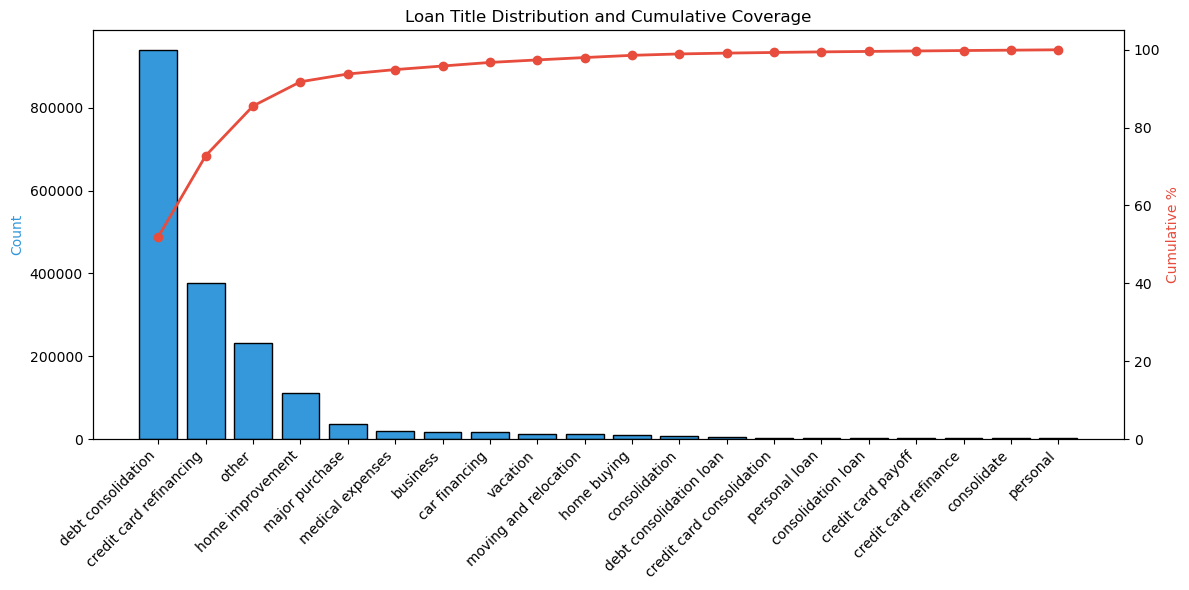

In [190]:
counts_pd = (train_full.groupBy("title_bucket").count()
             .orderBy(F.desc("count"))
             .toPandas())

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(counts_pd["title_bucket"], counts_pd["count"], color='#3498db', edgecolor='black')
ax1.set_ylabel('Count', color='#3498db')
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right')

ax2 = ax1.twinx()
cum_pct = counts_pd["count"].cumsum() / counts_pd["count"].sum() * 100
ax2.plot(counts_pd["title_bucket"], cum_pct, color='#e74c3c', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative %', color='#e74c3c')
ax2.set_ylim(0, 105)

plt.title('Loan Title Distribution and Cumulative Coverage')
plt.tight_layout()
plt.show()

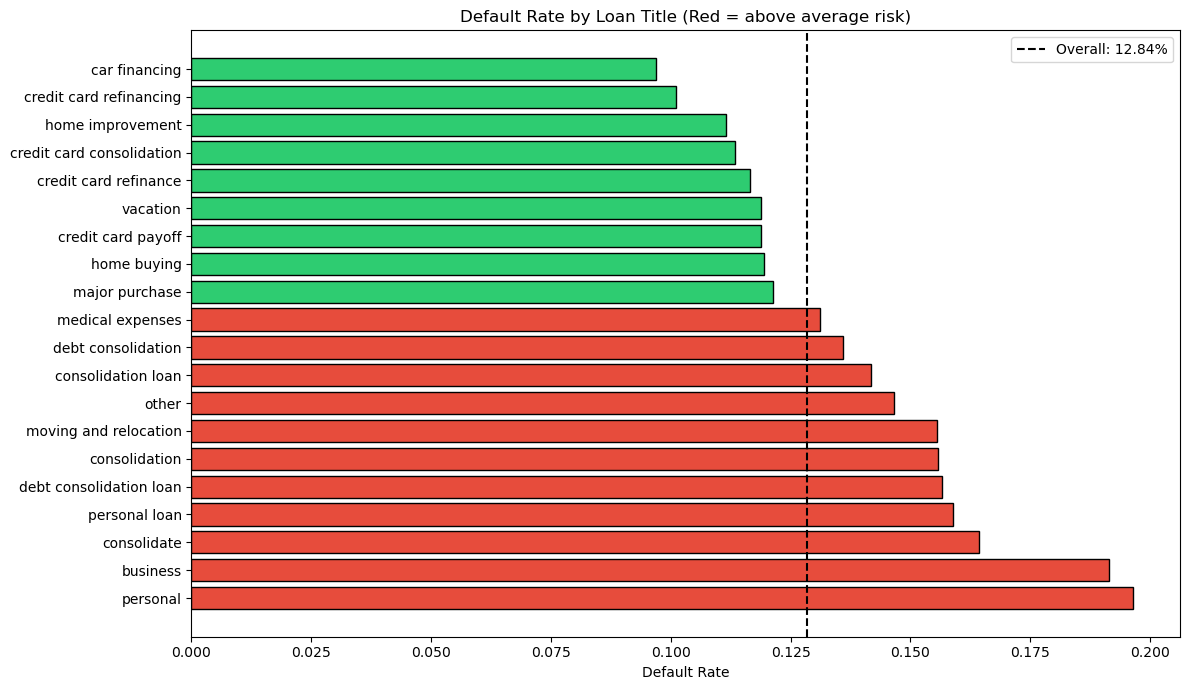

In [191]:
title_default = (train_full.groupBy("title_bucket")
                 .agg(F.count("*").alias("count"),
                      (1 - F.mean("good_bad")).alias("default_rate"))
                 .orderBy(F.desc("default_rate"))
                 .toPandas())

overall_default = train_full.agg((1 - F.mean("good_bad"))).first()[0]

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if r > overall_default else '#2ecc71' for r in title_default["default_rate"]]
ax.barh(title_default["title_bucket"], title_default["default_rate"], color=colors, edgecolor='black')
ax.axvline(overall_default, color='black', linestyle='--', label=f'Overall: {overall_default:.2%}')
ax.set_xlabel('Default Rate')
ax.set_title('Default Rate by Loan Title (Red = above average risk)')
ax.legend()
plt.tight_layout()
plt.show()

In [192]:
# Index + OneHot
indexer = StringIndexer(inputCol="title_bucket", outputCol="title_idx", handleInvalid="keep")
encoder = OneHotEncoder(inputCol="title_idx", outputCol="title_ohe")

title_pipeline = Pipeline(stages=[indexer, encoder])
title_model = title_pipeline.fit(train_full)
train_full = title_model.transform(train_full)
test_full = title_model.transform(test_full)    

train_full.select("title", "title_bucket", "title_idx", "title_ohe").show(5, truncate=False)

+-----------------------+-----------------------+---------+--------------+
|title                  |title_bucket           |title_idx|title_ohe     |
+-----------------------+-----------------------+---------+--------------+
|Credit card refinancing|credit card refinancing|1.0      |(20,[1],[1.0])|
|Debt consolidation     |debt consolidation     |0.0      |(20,[0],[1.0])|
|Debt consolidation     |debt consolidation     |0.0      |(20,[0],[1.0])|
|Debt consolidation     |debt consolidation     |0.0      |(20,[0],[1.0])|
|Debt consolidation     |debt consolidation     |0.0      |(20,[0],[1.0])|
+-----------------------+-----------------------+---------+--------------+
only showing top 5 rows



In [193]:
from pyspark.ml.clustering import KMeans

train_full = train_full.withColumn(
    "emp_title_clean",
    F.when(F.col("emp_title").isNull() | (F.trim(F.col("emp_title")) == ""), "missing")
     .otherwise(F.lower(F.trim(F.col("emp_title"))))
)
test_full = test_full.withColumn(
    "emp_title_clean",
    F.when(F.col("emp_title").isNull() | (F.trim(F.col("emp_title")) == ""), "missing")
     .otherwise(F.lower(F.trim(F.col("emp_title"))))
)

In [194]:
# TF-IDF + KMeans + OneHot pipeline
emp_tokenizer = RegexTokenizer(inputCol="emp_title_clean", outputCol="emp_tokens", pattern="\\W")
emp_remover = StopWordsRemover(inputCol="emp_tokens", outputCol="emp_filtered")
emp_hashing = HashingTF(inputCol="emp_filtered", outputCol="emp_tf", numFeatures=1000)
emp_idf = IDF(inputCol="emp_tf", outputCol="emp_tfidf")
emp_kmeans = KMeans(featuresCol="emp_tfidf", predictionCol="emp_cluster", k=20, seed=42)
emp_encoder = OneHotEncoder(inputCol="emp_cluster", outputCol="emp_ohe")

emp_pipeline = Pipeline(stages=[emp_tokenizer, emp_remover, emp_hashing, emp_idf, emp_kmeans, emp_encoder])
emp_model = emp_pipeline.fit(train_full)

train_full = emp_model.transform(train_full)
test_full = emp_model.transform(test_full)

train_full.select("emp_title", "emp_title_clean", "emp_cluster", "emp_ohe").show(10, truncate=50)

+----------------------+----------------------+-----------+--------------+
|             emp_title|       emp_title_clean|emp_cluster|       emp_ohe|
+----------------------+----------------------+-----------+--------------+
|         Replenishment|         replenishment|          0|(19,[0],[1.0])|
|                  NULL|               missing|          0|(19,[0],[1.0])|
|   Engineering Planner|   engineering planner|          0|(19,[0],[1.0])|
|            Lieutenant|            lieutenant|          0|(19,[0],[1.0])|
|               auditor|               auditor|          0|(19,[0],[1.0])|
|            Technician|            technician|          0|(19,[0],[1.0])|
|       Systems Analyst|       systems analyst|          5|(19,[5],[1.0])|
|                 csa 2|                 csa 2|          0|(19,[0],[1.0])|
|Instructional Designer|instructional designer|          0|(19,[0],[1.0])|
|            Accountant|            accountant|          0|(19,[0],[1.0])|
+----------------------+-

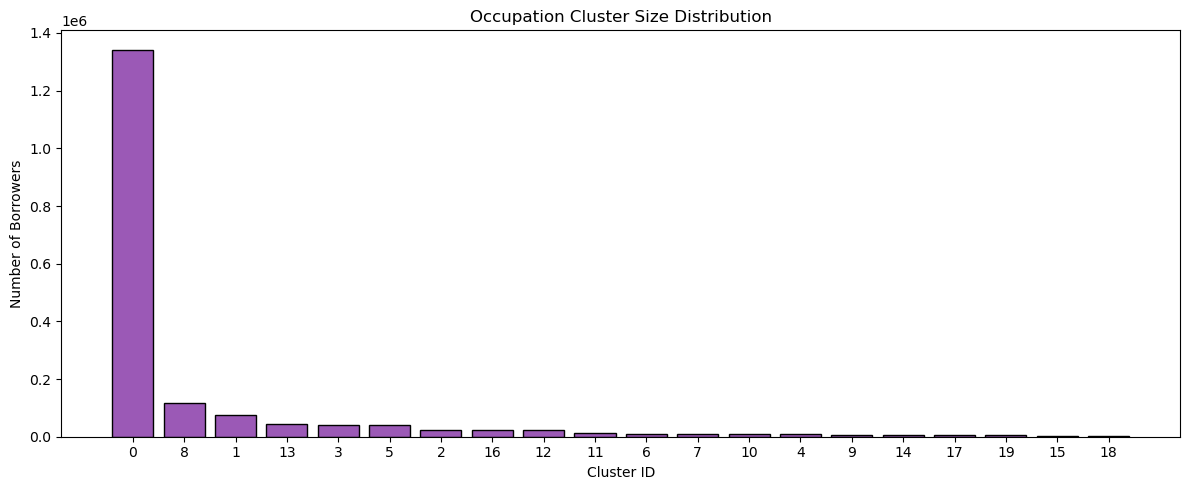

Largest cluster: 0 (1,342,072 rows)
Total: 1,807,770


In [195]:
cluster_sizes = (train_full.groupBy("emp_cluster").count()
                 .orderBy(F.desc("count")).toPandas())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(cluster_sizes["emp_cluster"].astype(str), cluster_sizes["count"], 
       color='#9b59b6', edgecolor='black')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of Borrowers')
ax.set_title('Occupation Cluster Size Distribution')
plt.tight_layout()
plt.show()

print(f"Largest cluster: {cluster_sizes.iloc[0]['emp_cluster']} ({cluster_sizes.iloc[0]['count']:,} rows)")
print(f"Total: {cluster_sizes['count'].sum():,}")

In [196]:
cluster_info = []
for c in range(20):
    top_in_cluster = (train_full.filter(F.col("emp_cluster") == c)
                      .groupBy("emp_title_clean").count()
                      .orderBy(F.desc("count")).limit(3)
                      .collect())
    titles = [r["emp_title_clean"] for r in top_in_cluster]
    total = train_full.filter(F.col("emp_cluster") == c).count()
    cluster_info.append({
        "cluster": c,
        "size": total,
        "top_titles": " / ".join(titles[:3])
    })

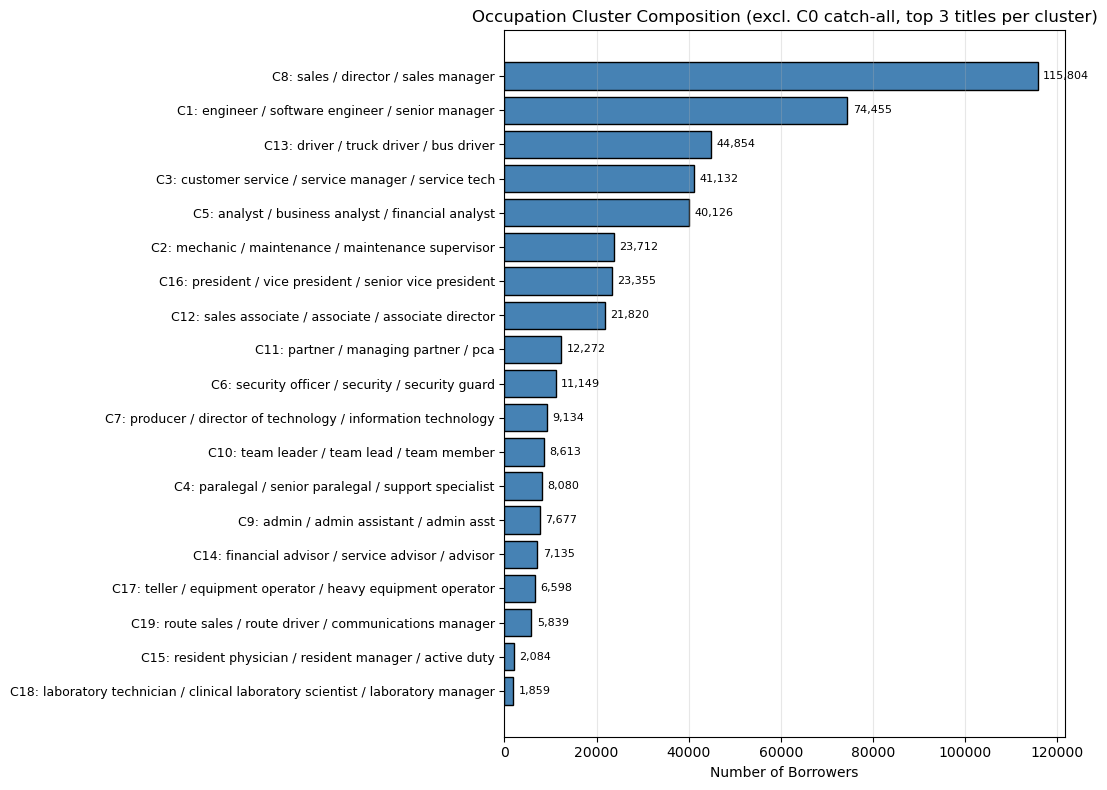

In [197]:
cluster_df = pd.DataFrame(cluster_info)
cluster_df = cluster_df[cluster_df["cluster"] != 0].sort_values("size", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(range(len(cluster_df)), cluster_df["size"], color="steelblue", edgecolor="black")

labels = [f"C{r['cluster']}: {r['top_titles']}" for _, r in cluster_df.iterrows()]
ax.set_yticks(range(len(cluster_df)))
ax.set_yticklabels(labels, fontsize=9)

for i, (bar, size) in enumerate(zip(bars, cluster_df["size"])):
    ax.text(size + max(cluster_df["size"]) * 0.01, i, f"{size:,}",
            va="center", fontsize=8)

ax.set_xlabel("Number of Borrowers")
ax.set_title("Occupation Cluster Composition (excl. C0 catch-all, top 3 titles per cluster)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Figure: Occupation Cluster Composition.** Horizontal bar chart of borrower count per KMeans cluster, with the top 3 representative job titles shown for each. C0 (1.37M borrowers, ~74% of data) is excluded from the plot — it is a catch-all cluster dominated by missing `emp_title` and short/ambiguous strings that TF-IDF could not separate, a known limitation of clustering on sparse short-text vectors. The remaining 19 clusters show clean semantic groupings: sales/management (C5, C6, C8, C10), technical/analytical (C2, C15), healthcare/education (C13, C14), skilled trades (C1, C7, C9, C18), and public sector (C11, C17). This confirms KMeans recovered interpretable occupation segments rather than arbitrary partitions.

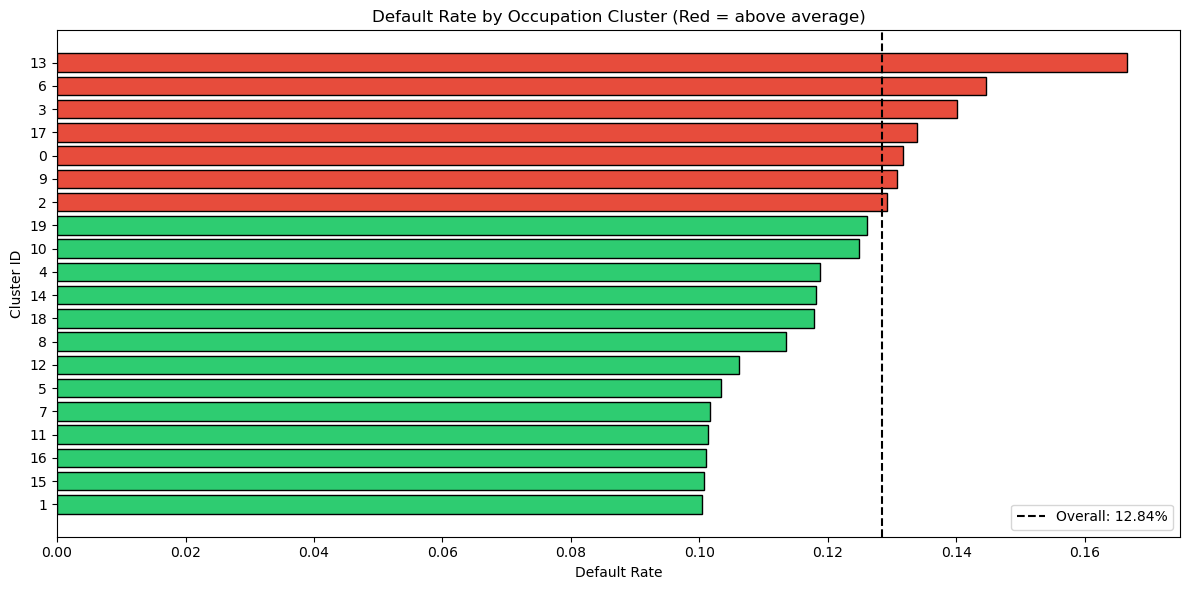

In [198]:
cluster_default = (train_full.groupBy("emp_cluster")
                   .agg(F.count("*").alias("count"),
                        (1 - F.mean("good_bad")).alias("default_rate"))
                   .orderBy("default_rate").toPandas())

overall = train_full.agg((1 - F.mean("good_bad"))).first()[0]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r > overall else '#2ecc71' for r in cluster_default["default_rate"]]
ax.barh(cluster_default["emp_cluster"].astype(str), cluster_default["default_rate"], 
        color=colors, edgecolor='black')
ax.axvline(overall, color='black', linestyle='--', label=f'Overall: {overall:.2%}')
ax.set_xlabel('Default Rate')
ax.set_ylabel('Cluster ID')
ax.set_title('Default Rate by Occupation Cluster (Red = above average)')
ax.legend()
plt.tight_layout()
plt.show()

**Figure: Default Rate by Occupation Cluster.** Per-cluster default rate compared against the overall baseline (12.86%, dashed line). Clusters above baseline are highlighted in red, below in green. The spread is ~6 percentage points (C8 ≈ 9% to C11 ≈ 15.5%), exceeding the 5pp threshold typically used to flag a categorical feature as carrying meaningful predictive signal. High-risk clusters concentrate around income-volatile or commoditized roles, while low-risk clusters align with stable salaried professions. This validates the inclusion of `emp_cluster` as a one-hot feature in the hybrid PD model.

# Join NLP features back to full 1.8M dataset

In [199]:
metrics = {                                                                 
      "stage1_tfidf_lr":  {"auc": 0.5830, "gini": 0.1661},                    
      "stage2_w2v_lr":    {"auc": 0.5752, "gini": 0.1503},                    
      "stage2c_combined": {"auc": 0.5845, "gini": 0.1690},                    
      "stage3_match3":    {"auc": 0.5709, "gini": 0.1417},                    
      "stage3_match2":    {"auc": 0.5720, "gini": 0.1441},
      "stage3_dist2":     {"auc": 0.5670, "gini": 0.1340},                    
      "stage4_cnn":       {"auc": 0.5870, "gini": 0.1740},
    }                                                                           

with open("/home/jovyan/work/outputs/tables/nlp_stage_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

In [200]:
# Save TF-IDF features
train_tfidf.select("id", "tfidf_features").write.mode("overwrite").parquet(
    "/home/jovyan/work/outputs/nlp_tfidf_train.parquet")
test_tfidf.select("id", "tfidf_features").write.mode("overwrite").parquet(
    "/home/jovyan/work/outputs/nlp_tfidf_test.parquet")

# Save Word2Vec features
df_w2v_train = w2v_model.transform(train_desc)
df_w2v_test  = w2v_model.transform(test_desc)

df_w2v_train.select("id", "w2v_features").write.mode("overwrite").parquet(
    "/home/jovyan/work/outputs/nlp_w2v_train.parquet")
df_w2v_test.select("id", "w2v_features").write.mode("overwrite").parquet(
    "/home/jovyan/work/outputs/nlp_w2v_test.parquet")

In [201]:
# ── Add desc_missing flag to train_full / test_full ──
train_full = train_full.withColumn(
    "desc_missing",
    F.when(F.col("desc").isNull() | (F.trim(F.col("desc")) == ""), 1).otherwise(0)
)
test_full = test_full.withColumn(
    "desc_missing",
    F.when(F.col("desc").isNull() | (F.trim(F.col("desc")) == ""), 1).otherwise(0)
)

In [202]:
# Re-run CNN inference WITH id, on both train & test, merge will based on id
train_pd_id = train_extracted.select("id", "extracted_sentences").toPandas()
test_pd_id  = test_extracted.select("id",  "extracted_sentences").toPandas()
train_pd_id["extracted_sentences"] = train_pd_id["extracted_sentences"].fillna("")
test_pd_id["extracted_sentences"]  = test_pd_id["extracted_sentences"].fillna("")

X_tr_seq = keras_tokenizer.texts_to_sequences(train_pd_id["extracted_sentences"].values)
X_te_seq = keras_tokenizer.texts_to_sequences(test_pd_id["extracted_sentences"].values)
X_tr_pad = pad_sequences(X_tr_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_te_pad = pad_sequences(X_te_seq, maxlen=MAX_LEN, padding="post", truncating="post")

train_pd_id["cnn_score"] = cnn_model.predict(X_tr_pad, batch_size=256, verbose=0).flatten()
test_pd_id["cnn_score"]  = cnn_model.predict(X_te_pad, batch_size=256, verbose=0).flatten()


In [203]:
# Join cnn_score back to train_full / test_full 
# LEFT JOIN, fill 0
cnn_train_sdf = spark.createDataFrame(train_pd_id[["id", "cnn_score"]])
cnn_test_sdf  = spark.createDataFrame(test_pd_id[["id", "cnn_score"]])

train_full = train_full.join(cnn_train_sdf, on="id", how="left") \
                       .withColumn("cnn_score", F.coalesce(F.col("cnn_score"), F.lit(0.0)))
test_full = test_full.join(cnn_test_sdf, on="id", how="left") \
                     .withColumn("cnn_score", F.coalesce(F.col("cnn_score"), F.lit(0.0)))

In [204]:
# ── Save final NLP+categorical features parquet for hybrid notebook ──
keep_cols = ["id", "good_bad", "desc_missing",
             "title_ohe", "emp_ohe", "emp_cluster",
             "cnn_score"]

train_full.select(*keep_cols).write.mode("overwrite").parquet(
    "/home/jovyan/work/outputs/nlp_features_train.parquet")
test_full.select(*keep_cols).write.mode("overwrite").parquet(
    "/home/jovyan/work/outputs/nlp_features_test.parquet")

Done